# Generation 1 Experiment Results

This notebook summarizes and visualizes the results from the Generation 1 counterfactual experiments, comparing different explainers, models, and the effect of constraints on counterfactual validity, feasibility, and computation time.

------

The first phase followed a 2×2×2 design in which two explainers, two prediction models, and two settings (with and without permitted_ranges) were combined. The purpose was to identify key patterns, limitations, and sensitivities in the counterfactual generation process.

In this phase, baseline models with standard parameters (300 trees) were used together with the following DiCE settings:
- total_CFs = 10
- stopping_threshold = 0.9
- posthoc_sparsity_param = 0.1
- maxiterations (genetic) = 500
- Permitted_ranges 

The Generation 1 experiments reveal clear differences between explainers, models, and the use of constraints. Random search showed the greatest variation and often produced implausible counterfactuals without constraints, especially with Random Forest. XGBoost was more stable in random search and achieved high validity in both settings, but still struggled with feasibility when constraints were absent. The genetic algorithm was consistently faster and more robust than random search, with short runtimes and high validity when constraints were applied. Without constraints, there were cases where validity was not achieved or changes were marginal. In summary, the results show that constraints are crucial for plausible counterfactuals, random search is sensitive to model choice and parameter settings, and the genetic algorithm is the most efficient and stable method given the data for this experiment. 

---

Table 3.3: Summary of Results – Generation 1  
--------------------------------------------------
| Explainer      | Model | Constraints | Validity | Feasibility | Time (s) | Comment                                                      |
|----------------|-------|-------------|----------|-------------|----------|--------------------------------------------------------------|
| random-search  | RF    | Yes         | Medium   | High        | 1028     | More stable but slow; some validity failures                 |
| random-search  | RF    | No          | Low      | Low         | 301      | Several implausible CFs; validity sometimes fails            |
| random-search  | XGB   | Yes         | High     | High        | 435      | Robust; mainly BMI adjustments                               |
| random-search  | XGB   | No          | High     | Medium      | 134      | Valid but often implausible CFs          
| genetic        | RF    | No          | Medium   | Low         | 19       | Some validity failures; some implausible CFs                 |
| genetic        | RF    | Yes         | High     | High        | 19       | Fast and stable; varied solutions                            |
| genetic        | XGB   | No          | Medium/Low | Low       | 11       | Marginal BMI changes insufficient for validity               |
| genetic        | XGB   | Yes         | Medium/High | High     | 9        | Fastest; one observation without validity                    |
                    |

In [1]:
# import
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

ROOT_DIR = Path(os.getenv("PROJECT_ROOT"))

RESULTS_CSV_PATH = ROOT_DIR / "analysis" / "gen_1_summary.csv"

print("root exists: ", ROOT_DIR.exists())
print("results is file: ", RESULTS_CSV_PATH.is_file())

root exists:  True
results is file:  True


In [4]:
df = pd.read_csv(RESULTS_CSV_PATH)

In [11]:
df.head(3)

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before_%,avg_risk_after_%,min_risk_after_%,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RF_highthres_2026-04-21,genetic,RandomForest,False,10,1000,0.9,9,85,31,36.5%,88.9%,49.4%,3.77,3.52,0.24,11.0,3.8,0.0,76.5,18.89,2.10,bmi: 100% | etfruit: 55% | eatveg: 52% | ...,gen_1_experiments/genetic_exp/RF_highthres_202...
1,RF_lowthres_2026-04-21,genetic,RandomForest,False,10,1000,0.1,9,61,38,62.3%,100.0%,47.5%,3.79,3.44,0.32,11.0,1.8,0.0,80.0,18.45,2.05,bmi: 100% | etfruit: 61% | cgtsmok: 50% |...,gen_1_experiments/genetic_exp/RF_lowthres_2026...
2,RF_prange_highthres_2026-04-29,genetic,RandomForest,True,10,1000,0.9,9,83,38,45.8%,100.0%,100.0%,2.50,2.29,0.21,11.0,3.0,0.0,78.7,18.83,2.09,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,gen_1_experiments/genetic_exp/RF_prange_highth...


In [6]:
df_highthres = df[df["stopping_threshold"] == 0.9].copy()

In [12]:
df_highthres

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before_%,avg_risk_after_%,min_risk_after_%,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path,Validity_%,Solved_%,Actionable_%,Time,Explainer,Model,Constraints,Config
0,RF_highthres_2026-04-21,genetic,RandomForest,False,10,1000,0.9,9,85,31,36.5%,88.9%,49.4%,3.77,3.52,0.24,11.0,3.8,0.0,76.5,18.89,2.10,bmi: 100% | etfruit: 55% | eatveg: 52% | ...,gen_1_experiments/genetic_exp/RF_highthres_202...,36.5,88.9,49.4,18.89,genetic,RandomForest,No Constraints,genetic\nRan
2,RF_prange_highthres_2026-04-29,genetic,RandomForest,True,10,1000,0.9,9,83,38,45.8%,100.0%,100.0%,2.50,2.29,0.21,11.0,3.0,0.0,78.7,18.83,2.09,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,gen_1_experiments/genetic_exp/RF_prange_highth...,45.8,100.0,100.0,18.83,genetic,RandomForest,With Constraints,genetic\nRan
4,XGB_highthres_2026-04-17,genetic,XGBoost,False,10,500,0.9,9,86,38,44.2%,77.8%,54.7%,3.74,3.52,0.28,10.2,2.6,0.2,77.9,10.59,1.18,bmi: 100% | etfruit: 63% | cgtsmok: 47% |...,gen_1_experiments/genetic_exp/XGB_highthres_20...,44.2,77.8,54.7,10.59,genetic,XGBoost,No Constraints,genetic\nXGB
5,XGB_prange_highthres_2026-04-17,genetic,XGBoost,True,10,500,0.9,9,84,43,51.2%,88.9%,100.0%,2.49,2.23,0.22,10.2,3.0,0.0,76.7,8.87,0.99,bmi: 100% | alcfreq: 33% | etfruit: 28% |...,gen_1_experiments/genetic_exp/XGB_prange_hight...,51.2,88.9,100.0,8.87,genetic,XGBoost,With Constraints,genetic\nXGB
7,RF_highthres_2026-04-21,random,RandomForest,False,10,1000,0.9,9,90,22,24.4%,88.9%,25.6%,1.82,1.76,0.14,11.0,4.8,0.0,70.6,301.11,33.46,alcfreq: 41% | bmi: 32% | dosprt: 27% | ...,gen_1_experiments/random_search_exp/RF_highthr...,24.4,88.9,25.6,301.11,random,RandomForest,No Constraints,random\nRan
9,RF_prange_highthres_2026-04-29,random,RandomForest,True,10,1000,0.9,9,90,22,24.4%,66.7%,100.0%,1.45,1.48,0.13,11.0,3.2,0.0,76.5,1028.51,114.28,bmi: 64% | dosprt: 27% | alcfreq: 18% | ...,gen_1_experiments/random_search_exp/RF_prange_...,24.4,66.7,100.0,1028.51,random,RandomForest,With Constraints,random\nRan
10,XGB_highthres_2026-04-17,random,XGBoost,False,10,1000,0.9,9,90,48,53.3%,100.0%,25.6%,1.69,1.69,0.13,10.2,2.2,0.0,80.8,133.85,14.87,bmi: 56% | etfruit: 27% | eatveg: 21% | ...,gen_1_experiments/random_search_exp/XGB_highth...,53.3,100.0,25.6,133.85,random,XGBoost,No Constraints,random\nXGB
11,XGB_prange_highthres_2026-04-17,random,XGBoost,True,10,1000,0.9,9,90,58,64.4%,100.0%,100.0%,1.47,1.47,0.13,10.2,2.0,0.0,82.1,435.36,48.37,bmi: 88% | dosprt: 16% | alcfreq: 14% | ...,gen_1_experiments/random_search_exp/XGB_prange...,64.4,100.0,100.0,435.36,random,XGBoost,With Constraints,random\nXGB


## Add Feasibility Scores

Based on Table 3.3, we'll add feasibility assessments to the high-threshold experiments.

## Visualization Approach

The DiCE authors use faceted line plots to show how metrics change across different conditions. This is a great approach for comparing:
- Different explainers (genetic vs random search)
- Different models (RF vs XGBoost)
- Different constraint settings (with/without permitted_range)

Let's create a similar visualization adapted to our Generation 1 results.

In [7]:
# Prepare data for visualization
# Convert percentage strings to floats (remove % sign first)
df_highthres["Validity_%"] = df_highthres["validity_%"].str.rstrip('%').astype(float)
df_highthres["Solved_%"] = df_highthres["solved_%"].str.rstrip('%').astype(float)
df_highthres["Actionable_%"] = df_highthres["actionable_%"].str.rstrip('%').astype(float)
df_highthres["Time"] = df_highthres["total_gen_time_sec"]

# Create labels
df_highthres["Explainer"] = df_highthres["explainer_type"]
df_highthres["Model"] = df_highthres["ml_model_type"]
df_highthres["Constraints"] = df_highthres["use_permitted_range"].map({True: "With Constraints", False: "No Constraints"})

# Create a categorical variable for x-axis ordering
df_highthres["Config"] = df_highthres.apply(
    lambda row: f"{row['Explainer']}\n{row['Model'][:3]}",
    axis=1
)

df_highthres[["Config", "Constraints", "Validity_%", "Solved_%", "Actionable_%", "Time"]].head(8)

,Config,Constraints,Validity_%,Solved_%,Actionable_%,Time
0,genetic\nRan,No Constraints,36.5,88.9,49.4,18.89
2,genetic\nRan,With Constraints,45.8,100.0,100.0,18.83
4,genetic\nXGB,No Constraints,44.2,77.8,54.7,10.59
5,genetic\nXGB,With Constraints,51.2,88.9,100.0,8.87
7,random\nRan,No Constraints,24.4,88.9,25.6,301.11
9,random\nRan,With Constraints,24.4,66.7,100.0,1028.51
10,random\nXGB,No Constraints,53.3,100.0,25.6,133.85
11,random\nXGB,With Constraints,64.4,100.0,100.0,435.36


### Alternative: Heatmap for Quick Overview

Another effective way to present these results is using a heatmap, which provides an immediate visual comparison across all configurations.

## FacetGrid: Compact Multi-Metric Comparison

Using FacetGrid to show all metrics in a compact, high-resolution grid layout.

In [8]:
# Reshape data for FacetGrid: melt to long format
df_melted = df_highthres.melt(
    id_vars=["Explainer", "Model", "use_permitted_range"],
    value_vars=["Validity_%", "Solved_%", "Actionable_%", "Time"],
    var_name="Metric",
    value_name="Value"
)

# Create configuration label
df_melted["Config"] = df_melted["Explainer"] + "_" + df_melted["Model"].str[:3]
df_melted["Constraints"] = df_melted["use_permitted_range"].map({True: "Yes", False: "No"})

df_melted.head()

,Explainer,Model,use_permitted_range,Metric,Value,Config,Constraints
0,genetic,RandomForest,False,Validity_%,36.5,genetic_Ran,No
1,genetic,RandomForest,True,Validity_%,45.8,genetic_Ran,Yes
2,genetic,XGBoost,False,Validity_%,44.2,genetic_XGB,No
3,genetic,XGBoost,True,Validity_%,51.2,genetic_XGB,Yes
4,random,RandomForest,False,Validity_%,24.4,random_Ran,No


### Swedish version for report

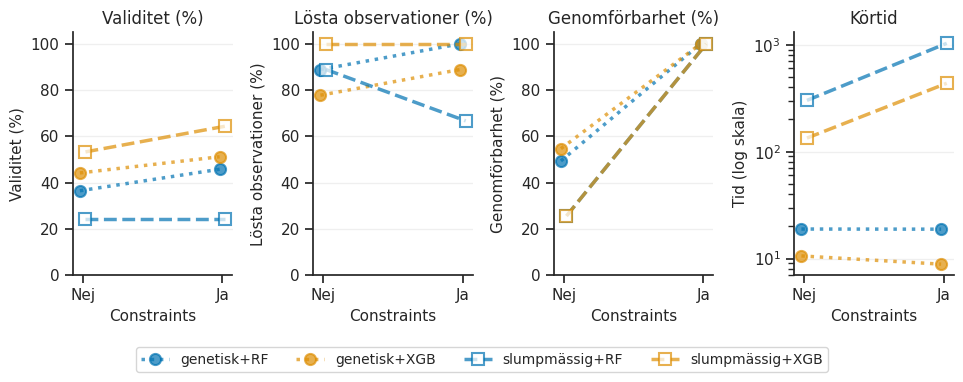

In [9]:
# FacetGrid with unique markers - Swedish version for thesis
sns.set_theme(style="ticks")

# Create the grid
g = sns.FacetGrid(
    df_melted,
    col="Metric",
    height=3.5,
    aspect=0.7,
    sharey=False,
    legend_out=True
)

# Plot each explainer-model combination with unique style
# Colorblind-friendly palette (blue/orange) and distinct line styles
colors = {"RandomForest": "#0173B2", "XGBoost": "#DE8F05"}  # Blue/Orange
linestyles = {"genetic": ":", "random": "--"}  # Dotted/Dashed
markers = {"genetic": "o", "random": "s"}  # Circle for genetic, square for random
offsets = {"genetic": -0.02, "random": 0.02}  # Small x-offset to avoid overlap

# Convert constraints to numeric for plotting with offset
constraint_map = {"No": 0, "Yes": 1}

for explainer in ["genetic", "random"]:
    for model in ["RandomForest", "XGBoost"]:
        subset = df_melted[
            (df_melted["Explainer"] == explainer) &
            (df_melted["Model"] == model)
        ]

        # Plot on each subplot
        for i, metric in enumerate(["Validity_%", "Solved_%", "Actionable_%", "Time"]):
            metric_data = subset[subset["Metric"] == metric].sort_values("Constraints")
            if not metric_data.empty:
                # Apply x-offset for visual separation
                x_values = [constraint_map[c] + offsets[explainer] for c in metric_data["Constraints"]]
                g.axes[0, i].plot(
                    x_values,
                    metric_data["Value"],
                    marker=markers[explainer],  # Different marker shapes
                    color=colors[model],
                    linestyle=linestyles[explainer],
                    markersize=8,
                    markeredgewidth=1.5,
                    markeredgecolor=colors[model],
                    markerfacecolor=colors[model] if explainer == "genetic" else "white",  # Hollow for random
                    linewidth=2.5,
                    alpha=0.7,
                    label=f"{explainer}+{model[:3]}"
                )

# Customize each subplot - Swedish labels for thesis
metric_labels = {
    "Validity_%": "Validitet (%)",
    "Solved_%": "Lösta observationer (%)",
    "Actionable_%": "Genomförbarhet (%)",
    "Time": "Körtid"
}
for ax, metric in zip(g.axes.flat, ["Validity_%", "Solved_%", "Actionable_%", "Time"]):
    ax.set_xlabel("Constraints", fontsize=11)
    ax.set_ylabel(metric_labels[metric], fontsize=11)
    ax.set_title(f"{metric_labels[metric]}", fontsize=12, fontweight="normal")  # Swedish title
    ax.grid(True, alpha=0.3, axis='y')

    # Set x-axis labels to Swedish
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Nej", "Ja"])

    # Set appropriate y-axis limits
    if metric in ["Validity_%", "Solved_%", "Actionable_%"]:
        ax.set_ylim(0, 105)  # Add some breathing room above 100%
    elif metric == "Time":
        ax.set_yscale("log")
        ax.set_ylabel("Tid (log skala)", fontsize=11)

# Create custom legend with Swedish labels
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["RandomForest"], marker=markers["genetic"],
           markersize=8, markerfacecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='genetisk+RF', linestyle=linestyles["genetic"], linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["XGBoost"], marker=markers["genetic"],
           markersize=8, markerfacecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='genetisk+XGB', linestyle=linestyles["genetic"], linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["RandomForest"], marker=markers["random"],
           markersize=8, markerfacecolor="white", markeredgecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='slumpmässig+RF', linestyle=linestyles["random"], linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["XGBoost"], marker=markers["random"],
           markersize=8, markerfacecolor="white", markeredgecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='slumpmässig+XGB', linestyle=linestyles["random"], linewidth=2.5, alpha=0.7),
]

g.fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05),
             frameon=True, fontsize=10, ncol=4)

# No suptitle - will be added in thesis document
g.tight_layout()
plt.show()

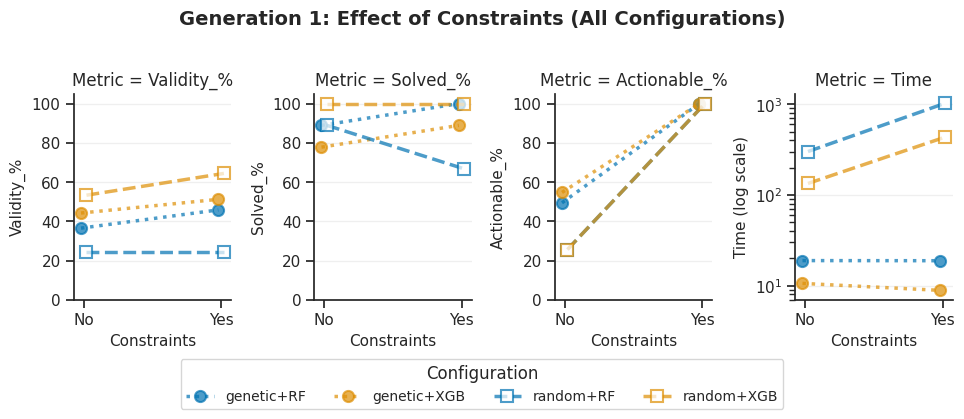

In [10]:
# FacetGrid with unique markers - one row, all metrics
sns.set_theme(style="ticks")

# Create the grid with both hue and style for unique identification
g = sns.FacetGrid(
    df_melted,
    col="Metric",
    height=3.5,
    aspect=0.7,
    sharey=False,
    legend_out=True
)

# Plot each explainer-model combination manually with unique style
# Colorblind-friendly palette (blue/orange) and distinct line styles
colors = {"RandomForest": "#0173B2", "XGBoost": "#DE8F05"}  # Blue/Orange
linestyles = {"genetic": ":", "random": "--"}  # Dotted/Dashed
markers = {"genetic": "o", "random": "s"}  # Circle for genetic, square for random
offsets = {"genetic": -0.02, "random": 0.02}  # Small x-offset to avoid overlap

# Convert constraints to numeric for plotting with offset
constraint_map = {"No": 0, "Yes": 1}

for explainer in ["genetic", "random"]:
    for model in ["RandomForest", "XGBoost"]:
        subset = df_melted[
            (df_melted["Explainer"] == explainer) &
            (df_melted["Model"] == model)
        ]

        # Plot on each subplot
        for i, metric in enumerate(["Validity_%", "Solved_%", "Actionable_%", "Time"]):
            metric_data = subset[subset["Metric"] == metric].sort_values("Constraints")
            if not metric_data.empty:
                # Apply x-offset for visual separation
                x_values = [constraint_map[c] + offsets[explainer] for c in metric_data["Constraints"]]
                g.axes[0, i].plot(
                    x_values,
                    metric_data["Value"],
                    marker=markers[explainer],  # Different marker shapes
                    color=colors[model],
                    linestyle=linestyles[explainer],
                    markersize=8,
                    markeredgewidth=1.5,
                    markeredgecolor=colors[model],
                    markerfacecolor=colors[model] if explainer == "genetic" else "white",  # Hollow for random
                    linewidth=2.5,
                    alpha=0.7,
                    label=f"{explainer}+{model[:3]}"
                )

# Customize each subplot
for ax, metric in zip(g.axes.flat, ["Validity_%", "Solved_%", "Actionable_%", "Time"]):
    ax.set_xlabel("Constraints", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

    # Set x-axis ticks back to "No" and "Yes"
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])

    # Set appropriate y-axis limits
    if metric in ["Validity_%", "Solved_%", "Actionable_%"]:
        ax.set_ylim(0, 105)  # Add some breathing room above 100%
    elif metric == "Time":
        ax.set_yscale("log")
        ax.set_ylabel("Time (log scale)", fontsize=11)



# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["RandomForest"], marker=markers["genetic"],
           markersize=8, markerfacecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='genetic+RF', linestyle=linestyles["genetic"], linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["XGBoost"], marker=markers["genetic"],
           markersize=8, markerfacecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='genetic+XGB', linestyle=linestyles["genetic"], linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["RandomForest"], marker=markers["random"],
           markersize=8, markerfacecolor="white", markeredgecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='random+RF', linestyle=linestyles["random"], linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["XGBoost"], marker=markers["random"],
           markersize=8, markerfacecolor="white", markeredgecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='random+XGB', linestyle=linestyles["random"], linewidth=2.5, alpha=0.7),
]

g.fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05),
             frameon=True, fontsize=10, title='Configuration', ncol=4)

g.fig.suptitle("Generation 1: Effect of Constraints (All Configurations)",
               fontsize=14, fontweight="bold", y=1.02)
g.tight_layout()
plt.show()